In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor


In [ ]:

# Cargar los datos
df2 = pd.read_csv('cash request.csv')
df = df2.copy()
# Convertir las columnas de fecha a formato datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['moderated_at'] = pd.to_datetime(df['moderated_at'], errors='coerce')

# Calcular la diferencia de tiempo en horas
df['moderated-created'] = (df['moderated_at'] - df['created_at']).dt.total_seconds() / 3600  # Convertir a horas
# Calcular la diferencia de tiempo SOLO para los registros con status 'rejected'
mask = df['status'] == 'rejected'
df.loc[mask, 'time_to_reject'] = (df.loc[mask, 'moderated_at'] - df.loc[mask, 'created_at']).dt.total_seconds() / 3600  # Convertir a horas

# Mostrar las primeras filas con la nueva columna
df


,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10 19:05:21.596873+00:00,2019-12-11 16:47:42.40783+00,804.0,2019-12-11 16:47:42.405646+00:00,NaN,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10 19:50:12.347780+00:00,2019-12-11 14:24:22.900054+00,231.0,2019-12-11 14:24:22.897988+00:00,NaN,2020-01-09 19:50:12.34778+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10 19:13:35.825460+00:00,2019-12-11 09:46:59.779773+00,191.0,2019-12-11 09:46:59.777728+00:00,NaN,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10 19:16:10.880172+00:00,2019-12-18 14:26:18.136163+00,761.0,2019-12-18 14:26:18.128407+00:00,NaN,2020-01-09 19:16:10.879606+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06 09:59:38.877376+00:00,2020-05-07 09:21:55.34008+00,7686.0,2020-05-07 09:21:55.320193+00:00,NaN,2020-06-05 22:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12 13:54:11.686225+00:00,2021-02-06 20:17:49.292493+00,13681.0,NaT,NaN,2021-02-06 11:00:00+00,2020-10-13,2021-02-06 20:17:49.257521+00,instant,2020-10-12 13:54:24.352856+00,NaN,NaN,NaN,NaN,NaN
23966,25243,50.0,money_back,2020-10-27 14:41:25.734910+00:00,2020-12-18 13:15:40.843946+00,NaN,NaT,30367.0,2020-11-03 22:00:00+00,2020-10-28,2020-12-01 13:26:53.787672+00,instant,2020-10-27 14:41:57.901946+00,completed,2020-11-12 23:20:41.928788+00,2020-12-01 13:26:53.815504+00,NaN,NaN
23967,22357,100.0,money_back,2020-10-20 07:58:04.006937+00:00,2021-02-05 12:19:30.656816+00,82122.0,NaT,NaN,2021-02-05 11:00:00+00,2020-10-21,2021-02-05 12:19:30.626289+00,instant,2020-10-20 07:58:14.171553+00,NaN,NaN,NaN,NaN,NaN
23968,20256,100.0,money_back,2020-10-10 05:40:55.700422+00:00,2021-02-05 13:14:19.707627+00,64517.0,NaT,NaN,2021-02-05 11:00:00+00,2020-10-12,2021-02-05 13:14:19.689906+00,instant,2020-10-10 05:41:23.368363+00,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   id                          23970 non-null  int64              
 1   amount                      23970 non-null  float64            
 2   status                      23970 non-null  object             
 3   created_at                  23970 non-null  datetime64[ns, UTC]
 4   updated_at                  23970 non-null  object             
 5   user_id                     21867 non-null  float64            
 6   moderated_at                15912 non-null  datetime64[ns, UTC]
 7   deleted_account_id          2104 non-null   float64            
 8   reimbursement_date          23970 non-null  object             
 9   cash_request_received_date  16289 non-null  object             
 10  money_back_date             16543 non-null  object        

In [ ]:
date_columns = ['created_at', 'moderated_at', 'updated_at', 'reimbursement_date',
                'cash_request_debited_date', 'cash_request_received_date',
                'money_back_date', 'send_at', 'reco_creation', 'reco_last_update']

# Verificar qué columnas existen en el DataFrame antes de convertirlas
existing_date_columns = [col for col in date_columns if col in df.columns]

# Aplicar el formato YYYY-MM-DD a las columnas de fecha existentes
df[existing_date_columns] = df[existing_date_columns].apply(pd.to_datetime, errors='coerce')
df[existing_date_columns] = df[existing_date_columns].apply(lambda x: x.dt.strftime('%Y-%m-%d'))

# Mostrar las primeras filas con las fechas en el nuevo formato
df.head()

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,2019-12-11,804.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,2019-12-11,231.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,2019-12-11,191.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,2019-12-18,761.0,2019-12-18,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,2020-05-07,7686.0,2020-05-07,NaN,NaN,NaN,NaN,regular,NaN,NaN,NaN,NaN,23.371234,23.371234


In [ ]:
df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')
df['moderated_at'] = pd.to_datetime(df['moderated_at'], errors='coerce')

# Contar cuántas veces son iguales
count_equal = (df['updated_at'] == df['moderated_at']).sum()

# Mostrar el resultado
print(f"Número de veces que 'updated_at' y 'moderated_at' son iguales: {count_equal}")

Número de veces que 'updated_at' y 'moderated_at' son iguales: 6502


En todos los casos donde son iguales, el estado es rejected.

In [ ]:
df = df.drop(columns=['recovery_status', 'reco_creation', 'reco_last_update', 'updated_at'])
df

,id,amount,status,created_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,804.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,231.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,191.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,761.0,2019-12-18,NaN,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,7686.0,2020-05-07,NaN,NaN,NaN,NaN,regular,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12,13681.0,NaT,NaN,NaN,2020-10-13,2021-02-06,instant,2020-10-12,NaN,NaN
23966,25243,50.0,money_back,2020-10-27,NaN,NaT,30367.0,NaN,2020-10-28,2020-12-01,instant,2020-10-27,NaN,NaN
23967,22357,100.0,money_back,2020-10-20,82122.0,NaT,NaN,NaN,2020-10-21,2021-02-05,instant,2020-10-20,NaN,NaN
23968,20256,100.0,money_back,2020-10-10,64517.0,NaT,NaN,NaN,2020-10-12,2021-02-05,instant,2020-10-10,NaN,NaN


In [ ]:
df.fillna({"user_id": df["deleted_account_id"]}, inplace=True)

In [ ]:
df.drop(columns=["deleted_account_id"], inplace=True)

In [ ]:
df

,id,amount,status,created_at,user_id,moderated_at,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,804.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,231.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,191.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,761.0,2019-12-18,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,7686.0,2020-05-07,NaN,NaN,NaN,regular,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12,13681.0,NaT,NaN,2020-10-13,2021-02-06,instant,2020-10-12,NaN,NaN
23966,25243,50.0,money_back,2020-10-27,30367.0,NaT,NaN,2020-10-28,2020-12-01,instant,2020-10-27,NaN,NaN
23967,22357,100.0,money_back,2020-10-20,82122.0,NaT,NaN,2020-10-21,2021-02-05,instant,2020-10-20,NaN,NaN
23968,20256,100.0,money_back,2020-10-10,64517.0,NaT,NaN,2020-10-12,2021-02-05,instant,2020-10-10,NaN,NaN


COHORTES

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['created_at'] = df['created_at'].dt.to_period('M')

In [ ]:
df['Cohorte'] = df.groupby('user_id')['created_at'].transform('min')
df.head()

,id,amount,status,created_at,user_id,moderated_at,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject,Cohorte
0,5,100.0,rejected,2019-12,804.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780,2019-12
1,70,100.0,rejected,2019-12,231.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597,2019-12
2,7,100.0,rejected,2019-12,191.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653,2019-12
3,10,99.0,rejected,2019-12,761.0,2019-12-18,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680,2019-12
4,1594,100.0,rejected,2020-05,7686.0,2020-05-07,NaN,NaN,NaN,regular,NaN,23.371234,23.371234,2020-05


In [ ]:
cohorte_amount_month = df.groupby(['Cohorte','created_at']).agg(Amount=('amount', 'sum')).reset_index()
cohorte_amount_month

,Cohorte,created_at,Amount
0,2019-11,2019-11,1.0
1,2019-11,2019-12,100.0
2,2019-11,2020-04,100.0
3,2019-11,2020-05,10.0
4,2019-11,2020-08,10.0
...,...,...,...
78,2020-09,2020-10,49865.0
79,2020-09,2020-11,1475.0
80,2020-10,2020-10,346445.0
81,2020-10,2020-11,1200.0


In [ ]:
cohort_sizes_initial = cohorte_amount_month.groupby('Cohorte').first()
cohort_sizes_initial


,created_at,Amount
Cohorte,,
2019-11,2019-11,1.0
2019-12,2019-12,27197.0
2020-01,2020-01,11464.0
2020-02,2020-02,8412.0
2020-03,2020-03,9499.0
2020-04,2020-04,25736.0
2020-05,2020-05,44883.0
2020-06,2020-06,180903.0
2020-07,2020-07,180330.0


In [ ]:
cohorte = cohorte_amount_month.pivot(index='Cohorte',
columns='created_at',
values='Amount')
cohorte

created_at,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11
Cohorte,,,,,,,,,,,,,
2019-11,1.0,100.0,NaN,NaN,NaN,100.0,10.0,NaN,NaN,10.0,5.0,6.0,NaN
2019-12,NaN,27197.0,10123.0,5881.0,7650.0,7900.0,8175.0,8805.0,6990.0,7790.0,4860.0,6655.0,100.0
2020-01,NaN,NaN,11464.0,2360.0,1660.0,3500.0,3020.0,2770.0,3010.0,2150.0,1970.0,2350.0,100.0
2020-02,NaN,NaN,NaN,8412.0,4740.0,4607.0,4350.0,4235.0,4405.0,4130.0,2555.0,3595.0,NaN
2020-03,NaN,NaN,NaN,NaN,9499.0,4250.0,4540.0,4850.0,4055.0,3390.0,2800.0,2700.0,50.0
2020-04,NaN,NaN,NaN,NaN,NaN,25736.0,14258.0,14320.0,11000.0,9915.0,7685.0,6450.0,NaN
2020-05,NaN,NaN,NaN,NaN,NaN,NaN,44883.0,30143.0,25725.0,21224.0,16350.0,15305.0,350.0
2020-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180903.0,92672.0,84491.0,60025.0,56525.0,400.0
2020-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180330.0,76873.0,49725.0,47313.0,500.0


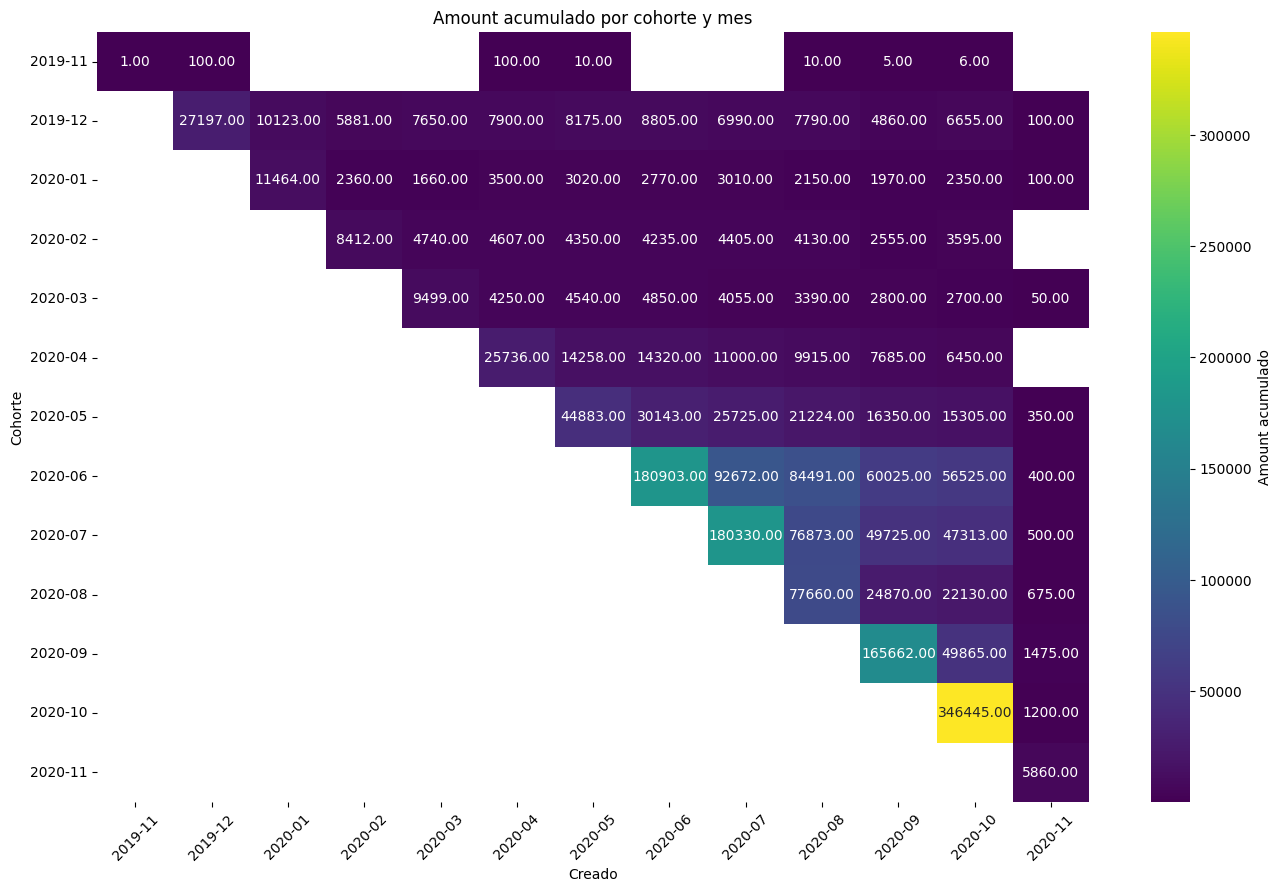

In [ ]:
plt.figure(figsize=(16, 10))
plt.title('Amount acumulado por cohorte y mes')
sns.heatmap(data=cohorte, annot=True, fmt='.2f',
cmap='viridis', cbar_kws={'label': 'Amount acumulado'})
plt.xlabel('Creado')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.ylabel('Cohorte')
plt.show()

In [ ]:
fila_2019_12 = cohorte.loc["2019-12"].T
fila_2019_12

,2019-12
created_at,
2019-11,NaN
2019-12,27197.0
2020-01,10123.0
2020-02,5881.0
2020-03,7650.0
2020-04,7900.0
2020-05,8175.0
2020-06,8805.0
2020-07,6990.0


In [ ]:
df_no_nulos = fila_2019_12.dropna().reset_index()
# Convertir la Serie en un DataFrame
# Renombrar columnas si es necesario
df_no_nulos.columns = ["created_at", "Acumulado"]

# Verificar la estructura
print(df_no_nulos.head())


  created_at  Acumulado
0    2019-12    27197.0
1    2020-01    10123.0
2    2020-02     5881.0
3    2020-03     7650.0
4    2020-04     7900.0


In [ ]:


# Asegurar que ambas listas tienen la misma longitud
if len(df_no_nulos["created_at"]) == len(df_no_nulos["Acumulado"]):
    print("Las listas están alineadas correctamente.")
else:
    print("Hay un desajuste en la cantidad de datos.")

# Asegurar que ambas listas están estructuradas como columnas de un DataFrame sin valores desalineados
df_no_nulos = df_no_nulos.dropna().reset_index(drop=True)

# Mostrar el DataFrame corregido

Las listas están alineadas correctamente.


In [ ]:
df_no_nulos["created_at"] = df_no_nulos["created_at"].dt.to_timestamp()
#df_no_nulos["Mes_Num"] = (df_no_nulos["created_at"] - df_no_nulos["created_at"].min()).dt.days // 30
#X = df_no_nulos[["Mes_Num"]].values  # Variable independiente (meses)
#y = df_no_nulos["Acumulado"].values  # Variable dependiente (ingresos acumulados)


In [ ]:
df_no_nulos


,created_at,Acumulado
0,2019-12-01,27197.0
1,2020-01-01,10123.0
2,2020-02-01,5881.0
3,2020-03-01,7650.0
4,2020-04-01,7900.0
5,2020-05-01,8175.0
6,2020-06-01,8805.0
7,2020-07-01,6990.0
8,2020-08-01,7790.0
9,2020-09-01,4860.0


In [ ]:

def graficar_ingresos_polinomicos(ingresos_heatmap, cohorte, fechas_futuras, grado):
    """
    Graficar la regresión polinómica de los ingresos acumulados de una cohorte específica,
    considerando fechas futuras con distancias reales basadas en el tiempo.

    Args:
        ingresos_heatmap (DataFrame): Tabla pivote con ingresos acumulados.
        cohorte (str): Cohorte a analizar (ej.: '2019-01').
        fechas_futuras (list): Lista de etiquetas para las fechas futuras.
        grado (int): Grado del polinomio para la regresión.
    """

    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    print("Datos Cohorte", datos_cohorte)
    # Crear la variable `fechas_cohorte` para asociar las fechas con los valores
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    print("Fechas cohorte", fechas_cohorte)
    # Extraer los valores de ingresos
    ingresos = datos_cohorte.values
    print("Ingresos", ingresos)
    # Filtrar las fechas y valores que no sean NaN
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]
    print("Fechas no nan", fechas_no_nan)
    print("Ingresos no nan", ingresos_no_nan)
    # Dividir los datos no nulos en 80% para interpolación y 20% para extrapolación

    num_interpolacion = int(0.8 * len(fechas_no_nan)) #indica el numero de datos que se usarán para inter
    fechas_interpolacion = fechas_no_nan[:num_interpolacion] #de los datos de fechas, coge el 80%
    ingresos_interpolacion = ingresos_no_nan[:num_interpolacion] #de los datos ingresos, coge el 80#
    fechas_extrapolacion = fechas_no_nan[num_interpolacion:] #coge el 20% restante para extrapolacion
    ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]

    # Crear la variable de fechas futuras
    fechas_futuras_dt = pd.to_datetime(fechas_futuras, format='%Y-%m')

    # Convertir fechas_cohorte y fechas_futuras_dt a Series para poder concatenarlas
    fechas_cohorte_series = pd.Series(fechas_cohorte)
    fechas_futuras_series = pd.Series(fechas_futuras_dt)

    # Concatenar las fechas completas (cohorte + futuras)
    fechas_completas_dt = pd.concat([fechas_cohorte_series, fechas_futuras_series])

    # Calcular los días desde la primera fecha de forma numérica usando `.days`
     #dias_desde_inicio = (fechas_completas_dt - fechas_completas_dt.iloc[0]).dt.days

    # Alinear los días de los datos de interpolación con los días originales
    dias_interpolacion = (fechas_interpolacion - fechas_completas_dt.iloc[0]).days.to_numpy()

    # Ajustar un modelo polinómico con los datos de interpolación
    poly = PolynomialFeatures(degree=grado)
    x_poly = poly.fit_transform(dias_interpolacion.reshape(-1, 1))  # Convertir a Numpy array y aplicar reshape

    #DESPUÉS DE BUSCAR HIPERPARÁMTEROS, VEMOS QUE EL GRADO MEJOR ES EL 3 Y
    modelo = LinearRegression()

    modelo.fit(x_poly, ingresos_interpolacion)


    # Predecir los valores para todas las fechas originales (incluidos los `NaN`)
    dias_originales = (fechas_cohorte - fechas_completas_dt.iloc[0]).days.to_numpy()
    dias_originales_poly = poly.transform(dias_originales.reshape(-1, 1))
    predicciones_originales = modelo.predict(dias_originales_poly)

    # Predecir los valores para fechas futuras
    dias_futuros = (fechas_futuras_dt - fechas_completas_dt.iloc[0]).days.to_numpy()
    dias_futuros_poly = poly.transform(dias_futuros.reshape(-1, 1))
    predicciones_futuras = modelo.predict(dias_futuros_poly)

    # Crear un DataFrame para mostrar las fechas, valores reales y valores predichos
    fechas_completas = pd.concat([fechas_cohorte_series, fechas_futuras_series])
    valores_reales = np.concatenate([ingresos, np.full_like(predicciones_futuras, np.nan)])
    valores_predichos = np.concatenate([predicciones_originales, predicciones_futuras])

    df_resultado = pd.DataFrame({
        'Fecha': fechas_completas.dt.to_period('M'),
        'Valor Real': valores_reales,
        'Valor Predicho': valores_predichos
    })

    # Imprimir la tabla
    print(df_resultado)

    # Graficar los datos de interpolación (80%) en azul
    plt.scatter(fechas_interpolacion, ingresos_interpolacion, label='Datos de interpolación (80%)', color='blue')

    # Graficar los datos de extrapolación (20%) en naranja
    plt.scatter(fechas_extrapolacion, ingresos_extrapolacion, label='Datos de extrapolación (20%)', color='orange')

    # Graficar la curva de tendencia (ajuste polinómico)
    plt.plot(fechas_cohorte, predicciones_originales, label='Curva de tendencia (Polinómica)', color='green', linestyle='--')

    # Graficar los valores predichos (faltantes) usando los índices donde los datos están ausentes
    fechas_nan = fechas_cohorte[np.isnan(ingresos)]
    predicciones_nan = predicciones_originales[np.isnan(ingresos)]
    plt.scatter(fechas_nan, predicciones_nan, label='Valores completados', color='green')

    # Graficar las predicciones futuras
    plt.scatter(fechas_futuras_dt, predicciones_futuras, label='Predicciones futuras', color='red')
    plt.plot(fechas_futuras_dt, predicciones_futuras, color='purple', linestyle='--', label='Curva futura (Polinómica)')

    # Configurar las etiquetas del eje X con las fechas completas
    plt.xticks(rotation=45)

    # Configuración del gráfico
    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Regresión Polinómica de Ingresos Acumulados (Cohorte {cohorte})')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


Datos Cohorte created_at
2019-11        NaN
2019-12    27197.0
2020-01    10123.0
2020-02     5881.0
2020-03     7650.0
2020-04     7900.0
2020-05     8175.0
2020-06     8805.0
2020-07     6990.0
2020-08     7790.0
2020-09     4860.0
2020-10     6655.0
2020-11      100.0
Freq: M, Name: 2019-12, dtype: float64
Fechas cohorte DatetimeIndex(['2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01',
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01'],
              dtype='datetime64[ns]', freq=None)
Ingresos [   nan 27197. 10123.  5881.  7650.  7900.  8175.  8805.  6990.  7790.
  4860.  6655.   100.]
Fechas no nan DatetimeIndex(['2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01',
               '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01',
               '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01'],
              dtype='datetime64[ns]', freq=None)
In

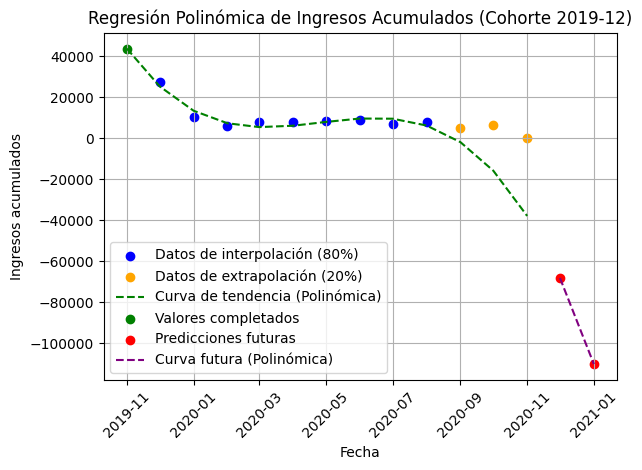

In [ ]:
cohorte2= "2019-12"
fechas_futuras2= "2020-12", "2021-01"
grado = 3
graficar_ingresos_polinomicos(cohorte, cohorte2, fechas_futuras2, grado)

In [ ]:
def buscar_mejor_k(X_train, y_train):
    param_grid_knn = {'n_neighbors': [2, 3, 5, 7, 10, 15, 20]}
    grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, refit=True, verbose=2, cv=5)
    grid_knn.fit(X_train, y_train)

    best_k = grid_knn.best_params_['n_neighbors']
    print(f"Mejor número de vecinos para KNN: {best_k}")
    return best_k

# Definir la función de graficación con KNN
def graficar_ingresos_knn(ingresos_heatmap, cohorte, fechas_futuras, k):
    """
    Graficar la regresión basada en KNN de los ingresos acumulados de una cohorte específica,
    considerando fechas futuras con distancias reales basadas en el tiempo.
    """

    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Dividir datos en interpolación y extrapolación
    num_interpolacion = int(0.8 * len(fechas_no_nan))
    fechas_interpolacion = fechas_no_nan[:num_interpolacion]
    ingresos_interpolacion = ingresos_no_nan[:num_interpolacion]
    fechas_extrapolacion = fechas_no_nan[num_interpolacion:]
    ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]

    # Crear la variable de fechas futuras
    fechas_futuras_dt = pd.to_datetime(fechas_futuras, format='%Y-%m')

    # Aplicar el modelo KNN
    knn_model = KNeighborsRegressor(n_neighbors=k)
    dias_interpolacion = np.array((fechas_interpolacion - fechas_no_nan[0]).days).reshape(-1, 1)
    knn_model.fit(dias_interpolacion, ingresos_interpolacion)

    # Predecir los valores para todas las fechas
    dias_originales = np.array((fechas_cohorte - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_originales = knn_model.predict(dias_originales)

    dias_futuros = np.array((fechas_futuras_dt - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_futuras = knn_model.predict(dias_futuros)

    # Asegurar que ingresos_extrapolacion y predicciones tengan el mismo tamaño
    min_length = min(len(ingresos_extrapolacion), len(predicciones_originales[num_interpolacion:]))
    ingresos_extrapolacion = ingresos_extrapolacion[:min_length]
    predicciones_extrapolacion = predicciones_originales[num_interpolacion:num_interpolacion+min_length]

    # Evaluar el error en extrapolación
    mse_extrapolacion = mean_squared_error(ingresos_extrapolacion, predicciones_extrapolacion)
    r2_extrapolacion = r2_score(ingresos_extrapolacion, predicciones_extrapolacion)

    print(f"MSE en extrapolación con KNN: {mse_extrapolacion}")
    print(f"R² en extrapolación con KNN: {r2_extrapolacion}")

    # Graficar los resultados
    plt.scatter(fechas_interpolacion, ingresos_interpolacion, label='Datos de interpolación (80%)', color='blue')
    plt.scatter(fechas_extrapolacion, ingresos_extrapolacion, label='Datos de extrapolación (20%)', color='orange')
    plt.plot(fechas_cohorte, predicciones_originales, label='Curva de tendencia (KNN)', color='green', linestyle='--')
    plt.scatter(fechas_futuras_dt, predicciones_futuras, label='Predicciones futuras', color='red')
    plt.plot(fechas_futuras_dt, predicciones_futuras, color='purple', linestyle='--', label='Curva futura (KNN)')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Regresión con KNN de Ingresos Acumulados (Cohorte {cohorte})')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

MSE en extrapolación con KNN: 23569838.88888889
R² en extrapolación con KNN: -2.08112985701037


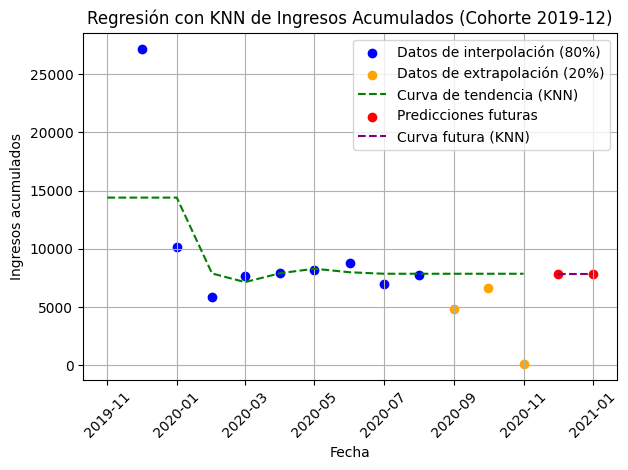

In [ ]:
cohorte2= "2019-12"

graficar_ingresos_knn(cohorte, cohorte2, fechas_futuras2, 3)

In [ ]:
# Definir la función para encontrar los mejores hiperparámetros de SVR
def buscar_mejor_svr(X_train, y_train):
    param_grid_svr = {
        'svr__C': [1, 10, 100, 500],
        'svr__gamma': [0.1, 0.01, 0.001, 'scale'],
        'svr__kernel': ['rbf', 'poly', 'sigmoid']
    }

    pipeline = make_pipeline(MinMaxScaler(), SVR())
    grid_svr = GridSearchCV(pipeline, param_grid_svr, refit=True, verbose=2, cv=5)
    grid_svr.fit(X_train, y_train)

    best_params = grid_svr.best_params_
    print(f"Mejores parámetros para SVR: {best_params}")
    return best_params

# Definir la función de graficación con SVR
def graficar_ingresos_svr(ingresos_heatmap, cohorte, fechas_futuras, C, gamma, kernel):
    """
    Graficar la regresión basada en SVR de los ingresos acumulados de una cohorte específica,
    considerando fechas futuras con distancias reales basadas en el tiempo.
    """

    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Dividir datos en interpolación y extrapolación
    num_interpolacion = int(0.8 * len(fechas_no_nan))
    fechas_interpolacion = fechas_no_nan[:num_interpolacion]
    ingresos_interpolacion = ingresos_no_nan[:num_interpolacion]
    fechas_extrapolacion = fechas_no_nan[num_interpolacion:]
    ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]

    # Crear la variable de fechas futuras
    fechas_futuras_dt = pd.to_datetime(fechas_futuras, format='%Y-%m')

    # Aplicar el modelo SVR con MinMaxScaler sin transformación polinómica
    svr_model = make_pipeline(MinMaxScaler(), SVR(C=C, gamma=gamma, kernel=kernel))
    dias_interpolacion = np.array((fechas_interpolacion - fechas_no_nan[0]).days).reshape(-1, 1)
    svr_model.fit(dias_interpolacion, ingresos_interpolacion)

    # Predecir los valores para todas las fechas
    dias_originales = np.array((fechas_cohorte - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_originales = svr_model.predict(dias_originales)

    dias_futuros = np.array((fechas_futuras_dt - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_futuras = svr_model.predict(dias_futuros)

    # Asegurar que ingresos_extrapolacion y predicciones tengan el mismo tamaño
    min_length = min(len(ingresos_extrapolacion), len(predicciones_originales[num_interpolacion:]))
    ingresos_extrapolacion = ingresos_extrapolacion[:min_length]
    predicciones_extrapolacion = predicciones_originales[num_interpolacion:num_interpolacion+min_length]

    # Evaluar el error en extrapolación
    mse_extrapolacion = mean_squared_error(ingresos_extrapolacion, predicciones_extrapolacion)
    r2_extrapolacion = r2_score(ingresos_extrapolacion, predicciones_extrapolacion)

    print(f"MSE en extrapolación con SVR: {mse_extrapolacion}")
    print(f"R² en extrapolación con SVR: {r2_extrapolacion}")

    # Graficar los resultados
    plt.scatter(fechas_interpolacion, ingresos_interpolacion, label='Datos de interpolación (80%)', color='blue')
    plt.scatter(fechas_extrapolacion, ingresos_extrapolacion, label='Datos de extrapolación (20%)', color='orange')
    plt.plot(fechas_cohorte, predicciones_originales, label='Curva de tendencia (SVR)', color='green', linestyle='--')
    plt.scatter(fechas_futuras_dt, predicciones_futuras, label='Predicciones futuras', color='red')
    plt.plot(fechas_futuras_dt, predicciones_futuras, color='purple', linestyle='--', label='Curva futura (SVR)')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Regresión con SVR de Ingresos Acumulados (Cohorte {cohorte})')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
cohorte2= "2019-12"
fechas_futuras2= "2020-12", "2021-01"
best_params = buscar_mejor_svr(X_train, y_train)
graficar_ingresos_svr(cohorte, cohorte2, fechas_futuras2, best_params['svr__C'], best_params['svr__gamma'], best_params['svr__kernel'])


NameError: name 'X_train' is not defined

In [ ]:
# Definir la función para encontrar los mejores hiperparámetros de SGDRegressor
def buscar_mejor_sgd(X_train, y_train):
    param_grid_sgd = {
        'sgd__alpha': [0.0001, 0.001, 0.01, 0.1],
        'sgd__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
        'sgd__eta0': [0.001, 0.01, 0.1]  # Tasa de aprendizaje inicial
    }

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('sgd', SGDRegressor(max_iter=10000, tol=1e-5))
    ])

    grid_sgd = GridSearchCV(pipeline, param_grid_sgd, refit=True, verbose=2, cv=5)
    grid_sgd.fit(X_train, y_train)

    best_params = grid_sgd.best_params_
    print(f"Mejores parámetros para SGD: {best_params}")
    return best_params

# Definir la función de graficación con SGDRegressor
def graficar_ingresos_sgd(ingresos_heatmap, cohorte, fechas_futuras, alpha, learning_rate, eta0):
    """
    Graficar la regresión basada en SGD de los ingresos acumulados de una cohorte específica,
    considerando fechas futuras con distancias reales basadas en el tiempo.
    """

    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Dividir datos en interpolación y extrapolación
    num_interpolacion = int(0.8 * len(fechas_no_nan))
    fechas_interpolacion = fechas_no_nan[:num_interpolacion]
    ingresos_interpolacion = ingresos_no_nan[:num_interpolacion]
    fechas_extrapolacion = fechas_no_nan[num_interpolacion:]
    ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]

    # Crear la variable de fechas futuras
    fechas_futuras_dt = pd.to_datetime(fechas_futuras, format='%Y-%m')

    # Aplicar el modelo SGD con MinMaxScaler
    sgd_model = Pipeline([
        ('scaler', MinMaxScaler()),
        ('sgd', SGDRegressor(alpha=alpha, learning_rate=learning_rate, eta0=eta0, max_iter=10000, tol=1e-5))
    ])

    dias_interpolacion = np.array((fechas_interpolacion - fechas_no_nan[0]).days).reshape(-1, 1)
    sgd_model.fit(dias_interpolacion, ingresos_interpolacion)

    # Predecir los valores para todas las fechas
    dias_originales = np.array((fechas_cohorte - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_originales = sgd_model.predict(dias_originales)

    dias_futuros = np.array((fechas_futuras_dt - fechas_no_nan[0]).days).reshape(-1, 1)
    predicciones_futuras = sgd_model.predict(dias_futuros)

    # Asegurar que ingresos_extrapolacion y predicciones tengan el mismo tamaño
    min_length = min(len(ingresos_extrapolacion), len(predicciones_originales[num_interpolacion:]))
    ingresos_extrapolacion = ingresos_extrapolacion[:min_length]
    predicciones_extrapolacion = predicciones_originales[num_interpolacion:num_interpolacion+min_length]

    # Evaluar el error en extrapolación
    mse_extrapolacion = mean_squared_error(ingresos_extrapolacion, predicciones_extrapolacion)
    r2_extrapolacion = r2_score(ingresos_extrapolacion, predicciones_extrapolacion)

    print(f"MSE en extrapolación con SGD: {mse_extrapolacion}")
    print(f"R² en extrapolación con SGD: {r2_extrapolacion}")

    # Graficar los resultados
    plt.scatter(fechas_interpolacion, ingresos_interpolacion, label='Datos de interpolación (80%)', color='blue')
    plt.scatter(fechas_extrapolacion, ingresos_extrapolacion, label='Datos de extrapolación (20%)', color='orange')
    plt.plot(fechas_cohorte, predicciones_originales, label='Curva de tendencia (SGD)', color='green', linestyle='--')
    plt.scatter(fechas_futuras_dt, predicciones_futuras, label='Predicciones futuras', color='red')
    plt.plot(fechas_futuras_dt, predicciones_futuras, color='purple', linestyle='--', label='Curva futura (SGD)')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Regresión con SGD de Ingresos Acumulados (Cohorte {cohorte})')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
best_params = buscar_mejor_sgd(X_train, y_train)
graficar_ingresos_sgd(cohorte, cohorte2, fechas_futuras2,
                      best_params['sgd__alpha'],
                      best_params['sgd__learning_rate'],
                      best_params['sgd__eta0'])


In [ ]:


k_values = [2, 5, 10]
results = {}

# Iterar sobre diferentes valores de K-Fold
for k in k_values:
    mse_scores = []
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        poly = PolynomialFeatures(degree=3)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_pred = model.predict(X_test_poly)

        mse_scores.append(mean_squared_error(y_test, y_pred))

    results[k] = mse_scores

# Graficar resultados en un solo gráfico con subplots
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 5), sharey=True)

for ax, k in zip(axes, k_values):
    ax.boxplot(results[k])
    ax.set_title(f'K={k}')
    ax.set_xlabel('Regresión Polinómica')
    ax.set_ylabel('MSE')

plt.suptitle('Comparación de K-Fold en Regresión Polinómica')
plt.show()



1️⃣ Presencia de outliers extremos

Hay algunos valores de MSE mucho más altos que el resto, lo que sugiere que en algunos folds el modelo está fallando gravemente.

2️⃣ Alta varianza en los errores

Si el boxplot muestra una gran dispersión, el modelo no generaliza bien en diferentes subconjuntos de datos.

3️⃣ MSE demasiado alto

Un MSE grande indica que el modelo está haciendo predicciones con mucho error.

In [ ]:





# Parámetros
k_folds = 10
grado_polinomio = 3
alpha_regularizacion = 0.01  # Controla la regularización L2

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
mse_scores = []
r2_differences = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Modelo con regresión polinómica + escalado + SGD
    modelo_sgd = make_pipeline(
        PolynomialFeatures(degree=grado_polinomio),
        StandardScaler(),
        SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', alpha=alpha_regularizacion, random_state=42)
    )

    modelo_sgd.fit(X_train, y_train)
    y_train_pred = modelo_sgd.predict(X_train)
    y_test_pred = modelo_sgd.predict(X_test)

    mse_scores.append(mean_squared_error(y_test, y_test_pred))

    # Calcular R^2 para train y test y su diferencia
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    r2_differences.append(r2_train - r2_test)

# Mostrar resultado promedio
print(f"MSE promedio con SGD: {np.mean(mse_scores)}")
print(f"Diferencia promedio de R^2 (Train - Test): {np.mean(r2_differences)}")

# Graficar resultados con boxplot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(mse_scores)
plt.xlabel('Regresión Polinómica con SGD')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Resultados de Validación Cruzada con SGDRegressor')

plt.subplot(1, 2, 2)
plt.boxplot(r2_differences)
plt.xlabel('Regresión Polinómica con SGD')
plt.ylabel('Diferencia R^2 (Train - Test)')
plt.title('Diferencia en R^2 entre Train y Test')

plt.show()



In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

def buscar_mejores_parametros(df_no_nulos, grado):
    """
    Buscar los mejores hiperparámetros para la regresión polinómica con Ridge y graficar todas las combinaciones.
    """
    df_no_nulos['created_at'] = pd.to_datetime(df_no_nulos['created_at'], errors='coerce')

    X = df_no_nulos[['created_at']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.6, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)
    X_extrap_scaled = scaler.transform(X_extrap)

    X = df_no_nulos['created_at'].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values

    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]

    X_train1, X_test1, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

    poly = PolynomialFeatures()
    X_train = poly.fit_transform(X_train1)
    X_test = poly.fit_transform(X_test1)
    X_poly = poly.fit_transform(X)


    param_grid = {
        'degree': [2, 3, 4, 5, 6],
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
    }

    resultados = []

    plt.figure(figsize=(15, 10))

    for i, degree in enumerate(param_grid['degree']):
        for j, alpha in enumerate(param_grid['alpha']):
            modelo = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), Ridge(alpha=alpha))
            modelo.fit(X_train, y_train)
            predicciones_originales = modelo.predict(X_poly)
            y_test_pred = modelo.predict(X_test)
            mse = mean_squared_error(y_test, y_test_pred)
            r2 = r2_score(y_test, y_test_pred)

            resultados.append((degree, alpha, mse, r2))

            plt.subplot(len(param_grid['degree']), len(param_grid['alpha']), i * len(param_grid['alpha']) + j + 1)
            plt.scatter(X_interp, y_interp, label='Datos de interpolación', color='blue', s=10)
            plt.scatter(X_test, y_test_pred, label='Datos de extrapolación', color='orange', s=10)

            plt.plot(X_poly, predicciones_originales, label=f'Predicción (grado {degree}, alpha {alpha})', color='green')
            plt.xticks(rotation=45, fontsize=6)
            plt.yticks(fontsize=6)
#            plt.legend(fontsize=6)
            plt.title(f'Grado {degree}, Alpha {alpha}', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Encontrar la mejor combinación según MSE
    best_result = min(resultados, key=lambda x: x[2])
    best_degree, best_alpha, best_mse, best_r2 = best_result

    print(f"Mejor grado del polinomio: {best_degree}")
    print(f"Mejor alpha para Ridge: {best_alpha}")
    print(f"Mejor MSE: {best_mse}")
    print(f"Mejor R²: {best_r2}")

    return best_degree, best_alpha


In [ ]:
df = df.set_index(pd.PeriodIndex(df['created_at'], freq='D'))


In [ ]:
df_no_nulos

,created_at,Acumulado
0,2019-12-01,27197.0
1,2020-01-01,10123.0
2,2020-02-01,5881.0
3,2020-03-01,7650.0
4,2020-04-01,7900.0
5,2020-05-01,8175.0
6,2020-06-01,8805.0
7,2020-07-01,6990.0
8,2020-08-01,7790.0
9,2020-09-01,4860.0


In [ ]:
cohorte2= "2019-12"
fechas_futuras2= "2020-12", "2021-01"
grado = 3
buscar_mejores_parametros(cohorte, '2019-12')


NameError: name 'buscar_mejores_parametros' is not defined

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

def buscar_mejores_parametros(ingresos_heatmap, cohorte):
    """
    Buscar los mejores hiperparámetros para la regresión polinómica con Ridge y graficar todas las combinaciones.
    """
    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    # Filtrar las fechas y valores que no sean NaN
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Dividir los datos en interpolación (80%) y extrapolación (20%)
    num_interpolacion = int(0.8 * len(fechas_no_nan))
    dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

    fechas_interpolacion = fechas_no_nan[:num_interpolacion]
    ingresos_interpolacion = ingresos_no_nan[:num_interpolacion]
    fechas_extrapolacion = fechas_no_nan[num_interpolacion:]
    ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]
    X_interpol, y_interpol = dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion]
    X_extrap, y_extrap = dias_desde_inicio[num_interpolacion:], ingresos_no_nan[num_interpolacion:]

    # Convertir fechas en días desde la primera fecha
    X_train, X_test, y_train, y_test = train_test_split(X_interpol, y_interpol, test_size=0.2, random_state=42)


    param_grid = {
        'degree': [4, 5,6,7,8],
        'alpha': [0.01, 0.1, 1, 10, 100]
    }

    resultados = []

    plt.figure(figsize=(15, 10))

    for i, degree in enumerate(param_grid['degree']):
        for j, alpha in enumerate(param_grid['alpha']):
            modelo = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), Ridge(alpha=alpha))
            modelo.fit(X_train, y_train)

            dias_originales = (fechas_cohorte - fechas_no_nan[0]).days.to_numpy().reshape(-1, 1)
            predicciones_originales = modelo.predict(dias_originales)
            y_train_pred= modelo.predict(X_train)
            predicciones = modelo.predict(X_test)
            mse = mean_squared_error(y_test, predicciones)
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, predicciones)

            resultados.append((degree, alpha, mse, r2_train, r2_test))

            plt.subplot(len(param_grid['degree']), len(param_grid['alpha']), i * len(param_grid['alpha']) + j + 1)
            plt.scatter(fechas_interpolacion, ingresos_interpolacion, label='Datos de interpolación', color='blue', s=10)
            plt.scatter(fechas_extrapolacion, ingresos_extrapolacion, label='Datos de extrapolación', color='orange', s=10)

            plt.plot(fechas_cohorte, predicciones_originales, label=f'Predicción (grado {degree}, alpha {alpha})', color='green')
            plt.xticks(rotation=45, fontsize=6)
            plt.yticks(fontsize=6)
#            plt.legend(fontsize=6)
            plt.title(f'Grado {degree}, Alpha {alpha}', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Encontrar la mejor combinación según MSE
    best_result = min(resultados, key=lambda x: x[2])
    best_degree, best_alpha, best_mse, best_r2train, best_r2test = best_result

    print(f"Mejor grado del polinomio: {best_degree}")
    print(f"Mejor alpha para Ridge: {best_alpha}")
    print(f"Mejor MSE: {best_mse}")
    print(f"Mejor R²train: {best_r2train}")
    print(f"Mejor R²test: {best_r2test}")


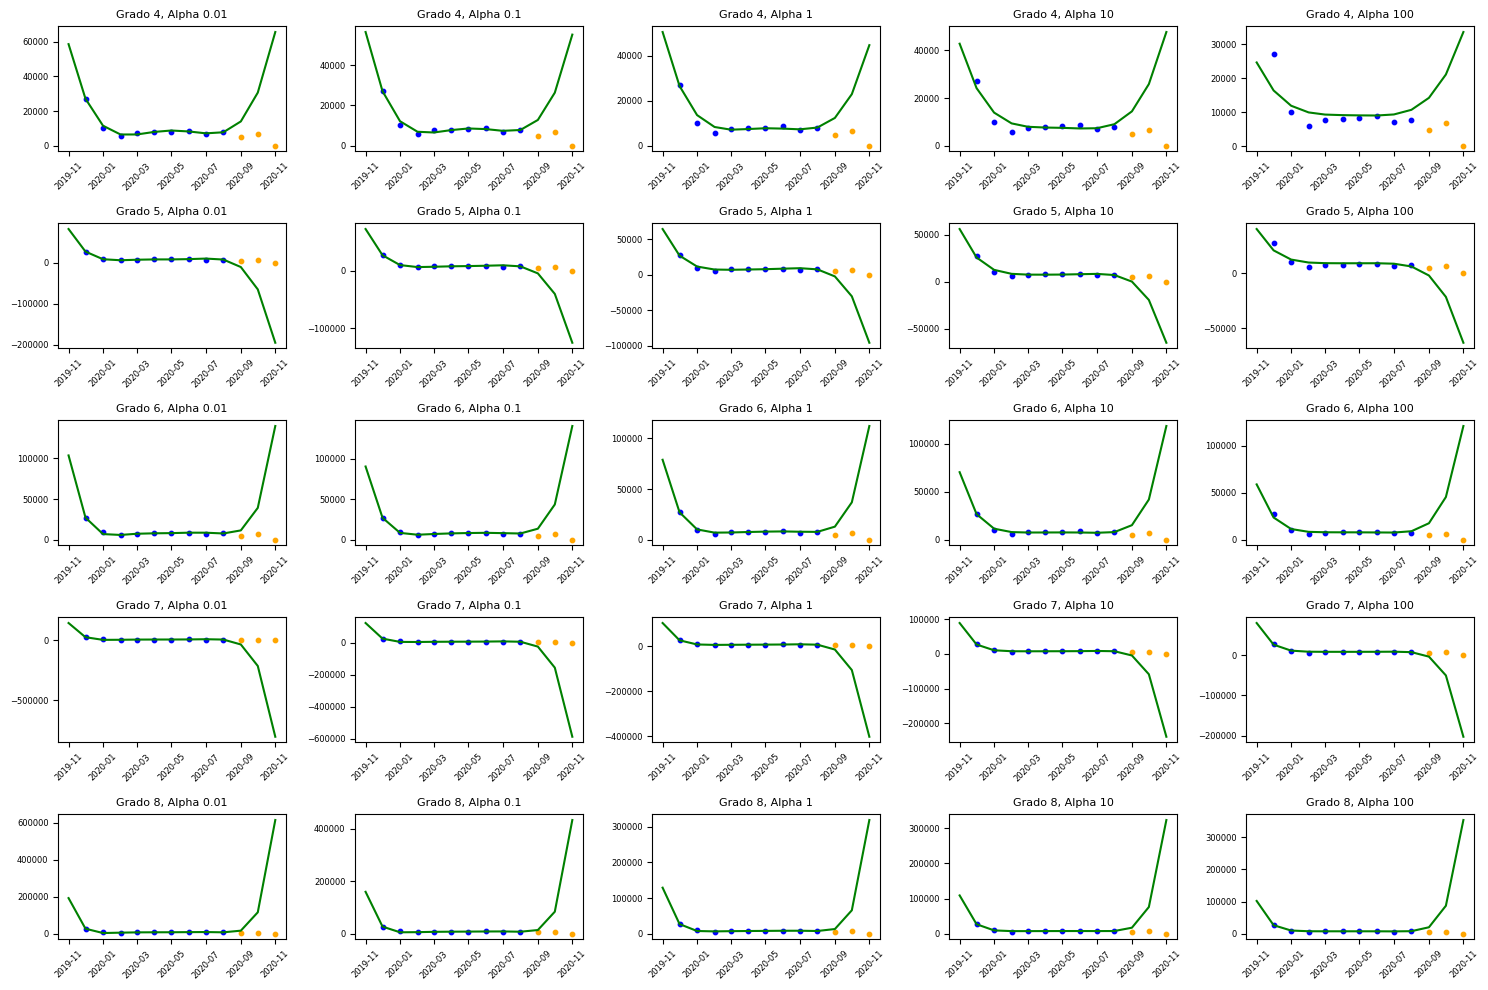

Mejor grado del polinomio: 8
Mejor alpha para Ridge: 100
Mejor MSE: 109204.10267633005
Mejor R²train: 0.9823347550495235
Mejor R²test: 0.9554981407107214


In [ ]:
cohorte2= "2019-12"
fechas_futuras2= "2020-12", "2021-01"
grado = 3
buscar_mejores_parametros(cohorte, '2019-12')


#graficar_ingresos_polinomicos2(cohorte, cohorte2, fechas_futuras2, grado)

R^2 Entrenamiento: 0.9823
R^2 Test: 0.9555
Diferencia R^2 (Train - Test): 0.0268
R^2 Interpolacion: 0.9822


,Fecha,Valor Real,Valor Predicho
0,2019-11-01,NaN,101972.150135
1,2019-12-01,27197.0,26609.215811
2,2020-01-01,10123.0,10077.421318
3,2020-02-01,5881.0,7866.352556
4,2020-03-01,7650.0,7723.503262
5,2020-04-01,7900.0,7724.155820
6,2020-05-01,8175.0,7728.228278
7,2020-06-01,8805.0,7688.798471
8,2020-07-01,6990.0,7455.113738
9,2020-08-01,7790.0,8057.745803


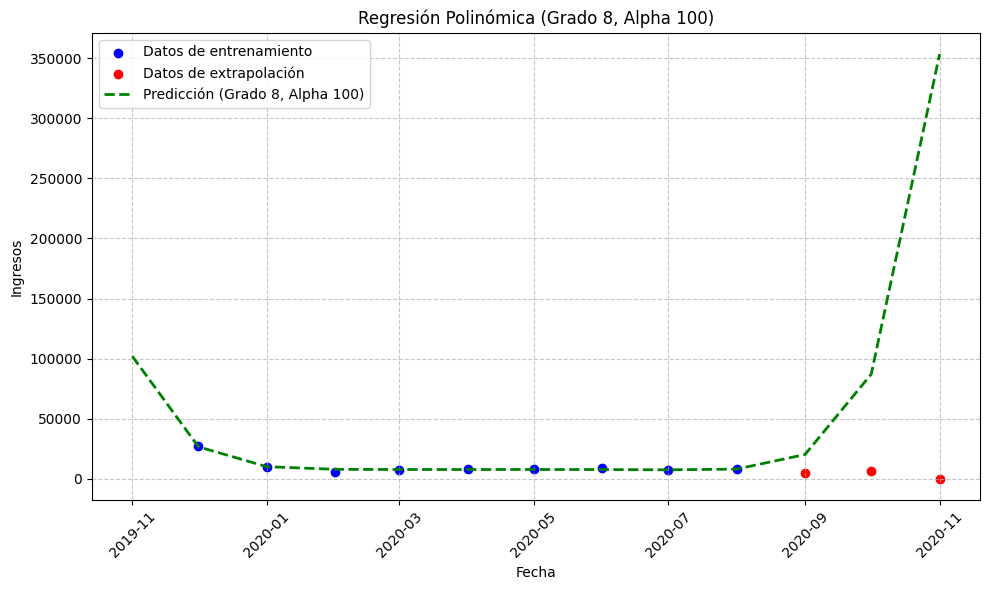

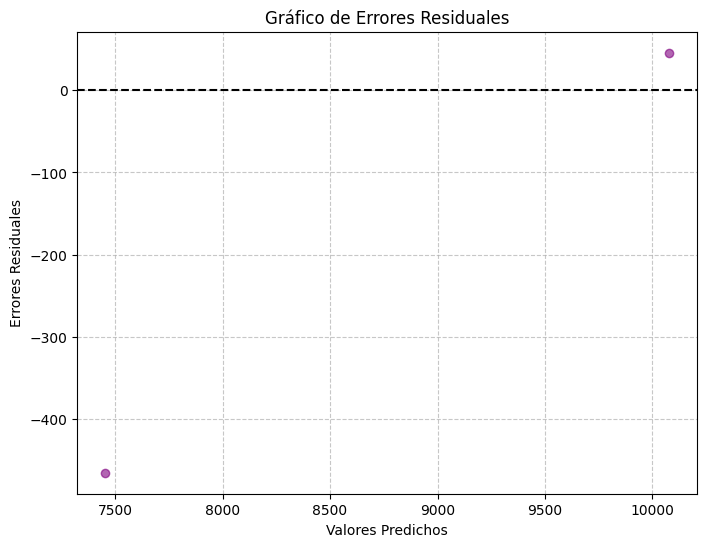

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 7 instead of 10.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than 

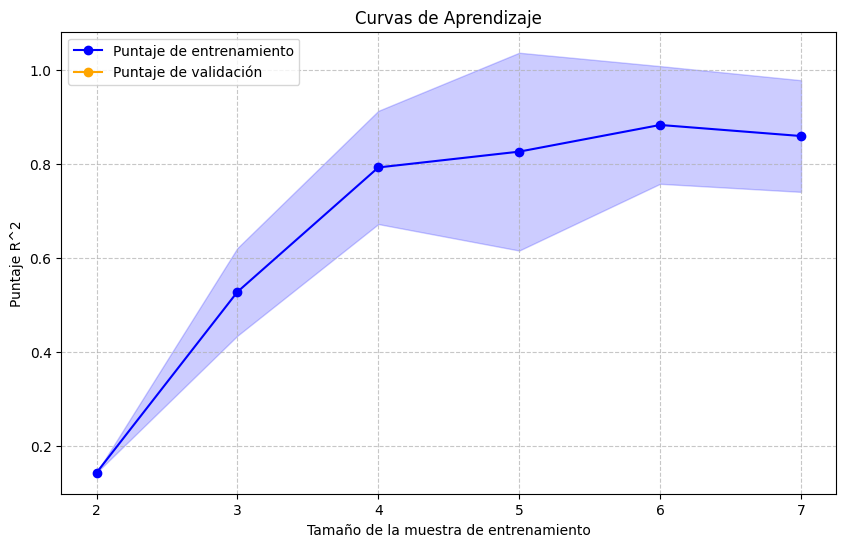

In [ ]:
from sklearn.model_selection import learning_curve

def graficar_un_parametro(ingresos_heatmap, cohorte, degree, alpha):
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    num_interpolacion = int(0.8 * len(fechas_no_nan))
    dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion],
        test_size=0.2, random_state=42
    )

    modelo = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree),
        Ridge(alpha=alpha)
    )
    modelo.fit(X_train, y_train)

    r2_train = modelo.score(X_train, y_train)
    r2_test = modelo.score(X_test, y_test)
    r2_diff = r2_train - r2_test

    dias_originales = (fechas_cohorte - fechas_no_nan[0]).days.to_numpy().reshape(-1, 1)
    predicciones_originales = modelo.predict(dias_originales)

    r2_interpolacion = r2_score(ingresos_no_nan[:num_interpolacion], modelo.predict(dias_desde_inicio[:num_interpolacion]))

    print(f"R^2 Entrenamiento: {r2_train:.4f}")
    print(f"R^2 Test: {r2_test:.4f}")
    print(f"Diferencia R^2 (Train - Test): {r2_diff:.4f}")
    print(f"R^2 Interpolacion: {r2_interpolacion:.4f}")

    df_resultados = pd.DataFrame({
        'Fecha': fechas_cohorte,
        'Valor Real': ingresos,
        'Valor Predicho': predicciones_originales
    })
    display(df_resultados)

    plt.figure(figsize=(10, 6))
    plt.scatter(fechas_no_nan[:num_interpolacion], ingresos_no_nan[:num_interpolacion], color='blue', label='Datos de entrenamiento')
    plt.scatter(fechas_no_nan[num_interpolacion:], ingresos_no_nan[num_interpolacion:], color='red', label='Datos de extrapolación')
    plt.plot(fechas_cohorte, predicciones_originales, color='green', linewidth=2, linestyle='--', label=f'Predicción (Grado {degree}, Alpha {alpha})')
    plt.xlabel('Fecha')
    plt.ylabel('Ingresos')
    plt.title(f'Regresión Polinómica (Grado {degree}, Alpha {alpha})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    errores = y_test - modelo.predict(X_test)
    plt.figure(figsize=(8, 6))
    plt.scatter(modelo.predict(X_test), errores, color='purple', alpha=0.6)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Valores Predichos')
    plt.ylabel('Errores Residuales')
    plt.title('Gráfico de Errores Residuales')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    train_sizes, train_scores, test_scores = learning_curve(modelo, dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion], cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10))

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Puntaje de entrenamiento', marker='o', color='blue')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Puntaje de validación', marker='o', color='orange')
    plt.fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1), np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), color='blue', alpha=0.2)
    plt.fill_between(train_sizes, np.mean(test_scores, axis=1) - np.std(test_scores, axis=1), np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), color='orange', alpha=0.2)
    plt.xlabel('Tamaño de la muestra de entrenamiento')
    plt.ylabel('Puntaje R^2')
    plt.title('Curvas de Aprendizaje')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    return modelo

modelo_1 = graficar_un_parametro(cohorte, '2019-12', 8, 100)

R^2 Entrenamiento: 0.9823
R^2 Test: 0.9555
Diferencia R^2 (Train - Test): 0.0268
R^2 Interpolacion: 0.9822


,Fecha,Valor Real,Valor Predicho
0,2019-11-01,NaN,101972.150135
1,2019-12-01,27197.0,26609.215811
2,2020-01-01,10123.0,10077.421318
3,2020-02-01,5881.0,7866.352556
4,2020-03-01,7650.0,7723.503262
5,2020-04-01,7900.0,7724.155820
6,2020-05-01,8175.0,7728.228278
7,2020-06-01,8805.0,7688.798471
8,2020-07-01,6990.0,7455.113738
9,2020-08-01,7790.0,8057.745803


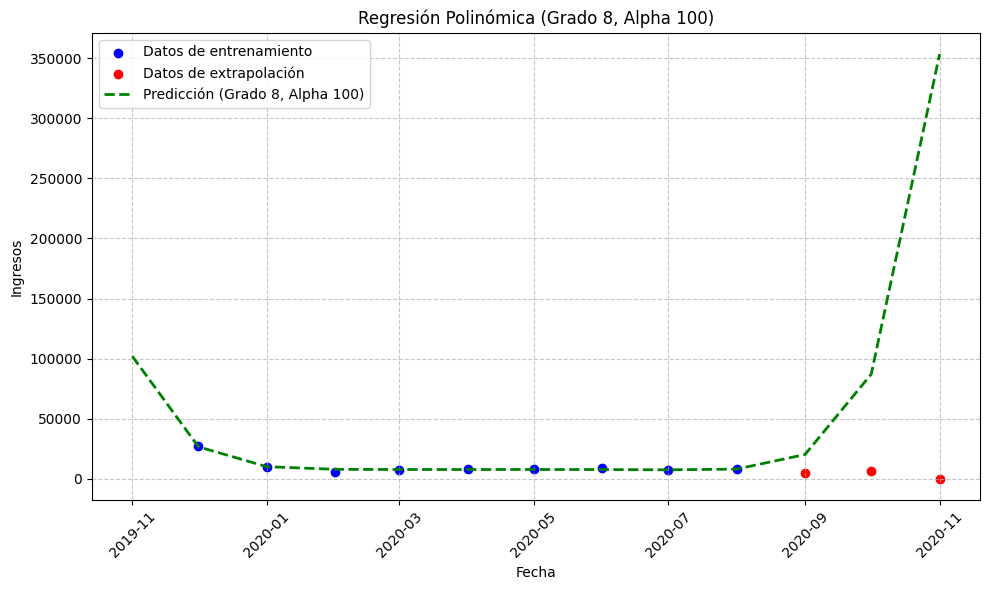

In [ ]:
def graficar_un_parametro(ingresos_heatmap, cohorte, degree, alpha):
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    num_interpolacion = int(0.8 * len(fechas_no_nan))
    dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion],
        test_size=0.2, random_state=42
    )

    modelo = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree),
        Ridge(alpha=alpha)
    )
    modelo.fit(X_train, y_train)

    r2_train = modelo.score(X_train, y_train)
    r2_test = modelo.score(X_test, y_test)
    r2_diff = r2_train - r2_test

    dias_originales = (fechas_cohorte - fechas_no_nan[0]).days.to_numpy().reshape(-1, 1)
    predicciones_originales = modelo.predict(dias_originales)

    r2_interpolacion = r2_score(ingresos_no_nan[:num_interpolacion], modelo.predict(dias_desde_inicio[:num_interpolacion]))

    print(f"R^2 Entrenamiento: {r2_train:.4f}")
    print(f"R^2 Test: {r2_test:.4f}")
    print(f"Diferencia R^2 (Train - Test): {r2_diff:.4f}")
    print(f"R^2 Interpolacion: {r2_interpolacion:.4f}")

    df_resultados = pd.DataFrame({
        'Fecha': fechas_cohorte,
        'Valor Real': ingresos,
        'Valor Predicho': predicciones_originales
    })
    display(df_resultados)

    plt.figure(figsize=(10, 6))
    plt.scatter(fechas_no_nan[:num_interpolacion], ingresos_no_nan[:num_interpolacion], color='blue', label='Datos de entrenamiento')
    plt.scatter(fechas_no_nan[num_interpolacion:], ingresos_no_nan[num_interpolacion:], color='red', label='Datos de extrapolación')
    plt.plot(fechas_cohorte, predicciones_originales, color='green', linewidth=2, linestyle='--', label=f'Predicción (Grado {degree}, Alpha {alpha})')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos')
    plt.title(f'Regresión Polinómica (Grado {degree}, Alpha {alpha})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return modelo

modelo_1 = graficar_un_parametro(cohorte, '2019-12', 8, 100)


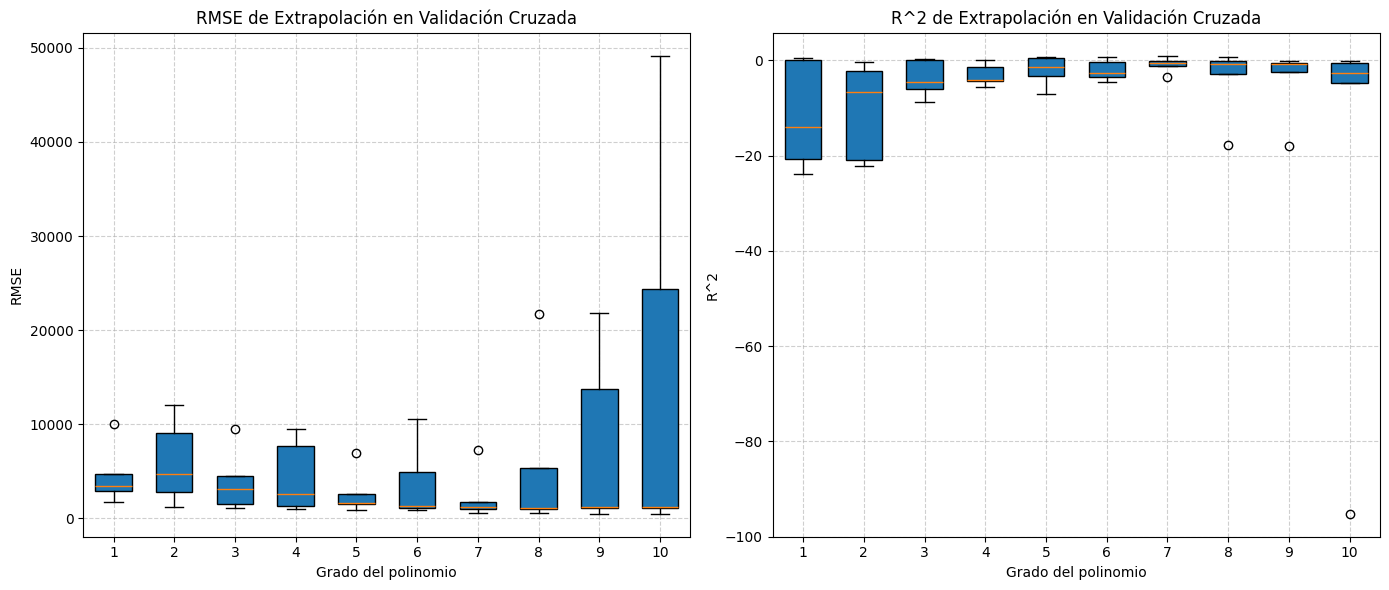

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

def evaluar_modelos_validacion_cruzada(ingresos_heatmap, cohorte, grados, alpha, cv=5):
    dif_r2 = []
    r2_interpol = []

    for degree in grados:
        datos_cohorte = ingresos_heatmap.loc[cohorte]
        fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
        ingresos = datos_cohorte.values

        fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
        ingresos_no_nan = ingresos[~np.isnan(ingresos)]

        dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        fold_dif_r2 = []
        fold_r2_interpol = []

        for train_index, test_index in kf.split(dias_desde_inicio):
            X_train, X_test = dias_desde_inicio[train_index], dias_desde_inicio[test_index]
            y_train, y_test = ingresos_no_nan[train_index], ingresos_no_nan[test_index]

            modelo = make_pipeline(
                StandardScaler(),
                PolynomialFeatures(degree=degree),
                Ridge(alpha=alpha)
            )
            modelo.fit(X_train, y_train)

            r2_train = modelo.score(X_train, y_train)
            r2_test = modelo.score(X_test, y_test)

            fold_dif_r2.append(r2_train - r2_test)
            fold_r2_interpol.append(r2_score(y_train, modelo.predict(X_train)))

        dif_r2.append(fold_dif_r2)
        r2_interpol.append(fold_r2_interpol)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].boxplot(dif_r2, widths=0.6, patch_artist=True)
    axes[0].set_xticks(range(1, len(grados)+1))
    axes[0].set_xticklabels(grados)
    axes[0].set_title('Diferencia de R^2 en Validación Cruzada')
    axes[0].set_xlabel('Grado del polinomio')
    axes[0].set_ylabel('Diferencia R^2 (Train - Test)')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].boxplot(r2_interpol, widths=0.6, patch_artist=True)
    axes[1].set_xticks(range(1, len(grados)+1))
    axes[1].set_xticklabels(grados)
    axes[1].set_title('R^2 de Interpolación en Validación Cruzada')
    axes[1].set_xlabel('Grado del polinomio')
    axes[1].set_ylabel('R^2 de Interpolación')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

grados = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
evaluar_modelos_validacion_cruzada(cohorte, '2019-12', grados, alpha=1, cv=5)

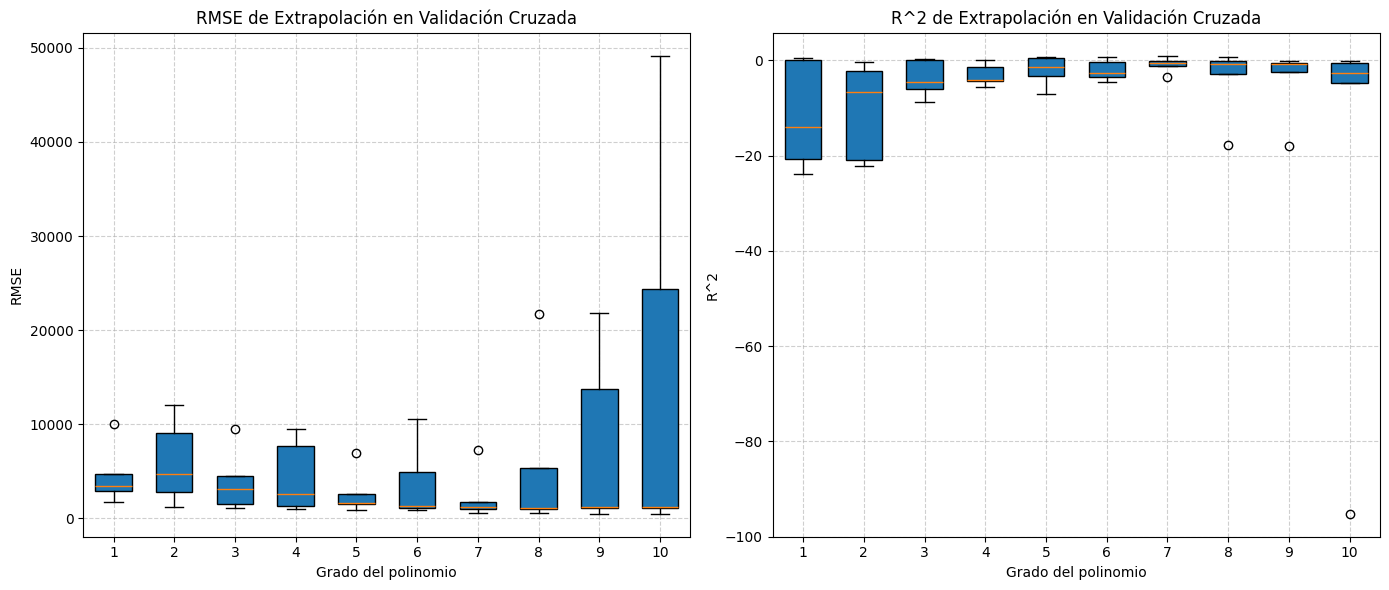

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold

def evaluar_modelos_validacion_cruzada(ingresos_heatmap, cohorte, grados, alpha, cv=5):
    rmse_extrap = []
    r2_extrap = []

    for degree in grados:
        datos_cohorte = ingresos_heatmap.loc[cohorte]
        fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
        ingresos = datos_cohorte.values

        fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
        ingresos_no_nan = ingresos[~np.isnan(ingresos)]

        dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        fold_rmse = []
        fold_r2 = []

        for train_index, test_index in kf.split(dias_desde_inicio):
            X_train, X_test = dias_desde_inicio[train_index], dias_desde_inicio[test_index]
            y_train, y_test = ingresos_no_nan[train_index], ingresos_no_nan[test_index]

            modelo = make_pipeline(
                StandardScaler(),
                PolynomialFeatures(degree=degree),
                Ridge(alpha=alpha)
            )
            modelo.fit(X_train, y_train)

            y_pred = modelo.predict(X_test)

            fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
            fold_r2.append(r2_score(y_test, y_pred))

        rmse_extrap.append(fold_rmse)
        r2_extrap.append(fold_r2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].boxplot(rmse_extrap, widths=0.6, patch_artist=True)
    axes[0].set_xticks(range(1, len(grados)+1))
    axes[0].set_xticklabels(grados)
    axes[0].set_title('RMSE de Extrapolación en Validación Cruzada')
    axes[0].set_xlabel('Grado del polinomio')
    axes[0].set_ylabel('RMSE')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].boxplot(r2_extrap, widths=0.6, patch_artist=True)
    axes[1].set_xticks(range(1, len(grados)+1))
    axes[1].set_xticklabels(grados)
    axes[1].set_title('R^2 de Extrapolación en Validación Cruzada')
    axes[1].set_xlabel('Grado del polinomio')
    axes[1].set_ylabel('R^2')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

grados = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
evaluar_modelos_validacion_cruzada(cohorte, '2019-12', grados, alpha=1, cv=5)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
# Código original del usuario para validación cruzada con Ridge Regression
degrees = range(1, 16)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = {degree: [] for degree in degrees}
r2_scores = {degree: [] for degree in degrees}

datos_cohorte = cohorte.loc['2019-12']
fechas_cohorte = pd.to_datetime(cohorte.columns.tolist(), format='%Y-%m')
ingresos = datos_cohorte.values

fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
ingresos_no_nan = ingresos[~np.isnan(ingresos)]

num_interpolacion = int(0.8 * len(fechas_no_nan))
dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

fechas_interpolacion = fechas_no_nan[:num_interpolacion]
ingresos_interpolacion = ingresos_no_nan[:num_interpolacion]
fechas_extrapolacion = fechas_no_nan[num_interpolacion:]
ingresos_extrapolacion = ingresos_no_nan[num_interpolacion:]
X_interpol, y_interpol = dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion]
X_extrap, y_extrap = dias_desde_inicio[num_interpolacion:], ingresos_no_nan[num_interpolacion:]
X_interp_scalar = StandardScaler().fit_transform(X_interpol)

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X_interp_scalar)

    model = Ridge(alpha=100)

    mse_cv_scores = cross_val_score(model, X_poly, y_interpol, cv=kf, scoring=make_scorer(mean_squared_error))
    r2_cv_scores = cross_val_score(model, X_poly, y_interpol, cv=kf, scoring=make_scorer(r2_score))

    rmse_scores[degree] = np.sqrt(np.abs(mse_cv_scores))
    r2_scores[degree] = np.abs(r2_cv_scores)

# Crear DataFrames y graficar resultados
df_rmse = pd.DataFrame.from_dict(rmse_scores, orient="index").T
df_r2 = pd.DataFrame.from_dict(r2_scores, orient="index").T

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
df_rmse.boxplot()
plt.yscale("log")
plt.xlabel("Grado del Polinomio")
plt.ylabel("RMSE (Escala Log)")
plt.title("Distribución de RMSE en Validación Cruzada")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.subplot(1, 2, 2)
df_r2.boxplot()
plt.yscale("log")
plt.xlabel("Grado del Polinomio")
plt.ylabel("R² (Escala Log)")
plt.title("Distribución de R² en Validación Cruzada")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extraer_coeficientes_ridge(modelo):
    """
    Extraer y visualizar los coeficientes del modelo Ridge.
    """
    # 1️⃣ Extraer coeficientes del modelo
    coefs = modelo.named_steps['ridge'].coef_.flatten()

    # 2️⃣ Crear etiquetas para cada coeficiente
    feature_labels = [f"x^{i}" for i in range(len(coefs))]

    # 3️⃣ Crear un DataFrame ordenado por magnitud del coeficiente
    df_coefs = pd.DataFrame({"Feature": feature_labels, "Peso": coefs})
    df_coefs["Peso Abs"] = np.abs(df_coefs["Peso"])
    df_coefs = df_coefs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs["Feature"], df_coefs["Peso"], color="skyblue")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor del Peso")
    plt.title("Importancia de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Ejemplo de uso:
extraer_coeficientes_ridge(modelo_1)

In [ ]:
def extraer_coeficientes_absolutos_ridge(modelo):
    """
    Extraer y visualizar los valores absolutos de los coeficientes del modelo Ridge.
    """
    # 1️⃣ Obtener los valores absolutos de los coeficientes
    coefs_abs = np.abs(modelo.named_steps['ridge'].coef_.flatten())

    # 2️⃣ Crear etiquetas para cada coeficiente polinómico
    feature_labels = [f"x^{i}" for i in range(len(coefs_abs))]

    # 3️⃣ Crear un DataFrame y ordenarlo por magnitud del coeficiente
    df_coefs_abs = pd.DataFrame({"Feature": feature_labels, "Peso Abs": coefs_abs})
    df_coefs_abs = df_coefs_abs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes absolutos
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs_abs["Feature"], df_coefs_abs["Peso Abs"], color="orange")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor Absoluto del Peso")
    plt.title("Importancia Absoluta de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
extraer_coeficientes_absolutos_ridge(modelo_1)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_modelo_con_diferentes_grados_g(ingresos_heatmap, cohorte, grados, alpha):
    """
    Evalúa el rendimiento del modelo de regresión polinómica para diferentes grados,
    mostrando la variabilidad del error (R² y MSE) en un gráfico de caja (boxplot).
    """
    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    # Filtrar valores no NaN
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Normalizar las fechas restando la primera fecha
    dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

    # Separar el 80% para interpolación y 20% para extrapolación
    num_interpolacion = int(0.8 * len(dias_desde_inicio))
    X_interpol, y_interpol = dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion]

    # Separar el conjunto de interpolación en 80% train y 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_interpol, y_interpol, test_size=0.2, random_state=42)

    resultados = []

    for grado in grados:
        # Crear y entrenar el modelo con Ridge
        modelo = make_pipeline(
            PolynomialFeatures(degree=grado),
            StandardScaler(),
            Ridge(alpha=alpha)
        )
        modelo.fit(X_train, y_train)

        # Evaluar el modelo en Train y Test
        y_train_pred = modelo.predict(X_train)
        y_test_pred = modelo.predict(X_test)

        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        mse_train = mean_squared_error(y_train, y_train_pred)
        mse_test = mean_squared_error(y_test, y_test_pred)

        # Guardar resultados para el boxplot
        resultados.append([grado, 'Train', r2_train, mse_train])
        resultados.append([grado, 'Test', r2_test, mse_test])

    # Crear DataFrame para la visualización
    df_resultados = pd.DataFrame(resultados, columns=['Grado', 'Conjunto', 'R²', 'MSE'])

    # Graficar el rendimiento en R²
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Grado', y='R²', hue='Conjunto', data=df_resultados, palette=['blue', 'orange'])
    sns.stripplot(x='Grado', y='R²', hue='Conjunto', data=df_resultados, palette=['blue', 'orange'], dodge=True, alpha=0.5)
    plt.title('Comparación de R² para Diferentes Grados del Polinomio')
    plt.xlabel('Grado del Polinomio')
    plt.ylabel('R²')
    plt.legend(title='Conjunto', loc='lower right')
    plt.grid()
    plt.show()

    # Graficar el rendimiento en MSE
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Grado', y='MSE', hue='Conjunto', data=df_resultados, palette=['blue', 'orange'])
    sns.stripplot(x='Grado', y='MSE', hue='Conjunto', data=df_resultados, palette=['blue', 'orange'], dodge=True, alpha=0.5)
    plt.title('Comparación de MSE para Diferentes Grados del Polinomio')
    plt.xlabel('Grado del Polinomio')
    plt.ylabel('Error Cuadrático Medio (MSE)')
    plt.legend(title='Conjunto', loc='upper right')
    plt.grid()
    plt.show()


In [ ]:
cohorte2= "2019-12"
fechas_futuras2= "2020-12", "2021-01"
grados = [2, 3, 4, 5, 6]
evaluar_modelo_con_diferentes_grados_g(cohorte, cohorte2, grados, alpha=1.0)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluar_modelos_polinomicos(ingresos_heatmap, cohorte, fechas_futuras):
    """
    Probar diferentes grados del polinomio (2 a 7) y diferentes valores de alpha
    (0.0001, 0.001, 0.01, 0.1, 1, 10, 100) y graficar cada modelo en una cuadrícula.
    """
    grados = [2, 3, 4, 5, 6, 7]
    alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

    # Seleccionar los datos de la cohorte solicitada
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    # Filtrar valores no NaN
    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    # Normalizar las fechas restando la primera fecha
    dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

    # Separar el conjunto en 80% interpolación y 20% extrapolación
    num_interpolacion = int(0.8 * len(dias_desde_inicio))
    X_interpol, y_interpol = dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion]
    X_extrap, y_extrap = dias_desde_inicio[num_interpolacion:], ingresos_no_nan[num_interpolacion:]

    # Separar el conjunto de interpolación en 80% train y 20% test con la misma semilla
    X_train, X_test, y_train, y_test = train_test_split(X_interpol, y_interpol, test_size=0.2, random_state=42)

    fig, axes = plt.subplots(len(grados), len(alphas), figsize=(18, 12))
    fig.tight_layout(pad=3.0)

    for i, grado in enumerate(grados):
        for j, alpha in enumerate(alphas):
            # Crear y entrenar el modelo con Ridge
            modelo = make_pipeline(
                PolynomialFeatures(degree=grado),
                StandardScaler(),
                Ridge(alpha=alpha)
            )
            modelo.fit(X_train, y_train)

            # Evaluación del modelo
            r2_train = r2_score(y_train, modelo.predict(X_train))
            r2_test = r2_score(y_test, modelo.predict(X_test))
            diferencia_r2 = abs(r2_train - r2_test)

            # Predicciones para fechas completas
            dias_originales = (fechas_cohorte - fechas_no_nan.min()).days.to_numpy()
            predicciones_originales = modelo.predict(dias_originales.reshape(-1, 1))

            # Predicciones para fechas futuras
            fechas_futuras_dt = pd.to_datetime(fechas_futuras, format='%Y-%m')
            dias_futuros = (fechas_futuras_dt - fechas_no_nan.min()).days.to_numpy()
            predicciones_futuras = modelo.predict(dias_futuros.reshape(-1, 1))

            # Graficar en la cuadrícula
            ax = axes[i, j]
            ax.scatter(fechas_no_nan[:num_interpolacion], y_interpol, label='Train', color='blue', s=10)
            ax.scatter(fechas_no_nan[num_interpolacion:], y_extrap, label='Extrapolación', color='orange', s=10)
            ax.plot(fechas_cohorte, predicciones_originales, label='Curva Polinómica', color='green', linestyle='--')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'Grado {grado}, Alpha {alpha}', fontsize=10)
            ax.text(0.5, -0.2, f'Dif R²: {diferencia_r2:.4f}', transform=ax.transAxes, fontsize=8, ha='center')

    plt.show()


In [ ]:
evaluar_modelos_polinomicos(cohorte,cohorte2, fechas_futuras2)
